1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


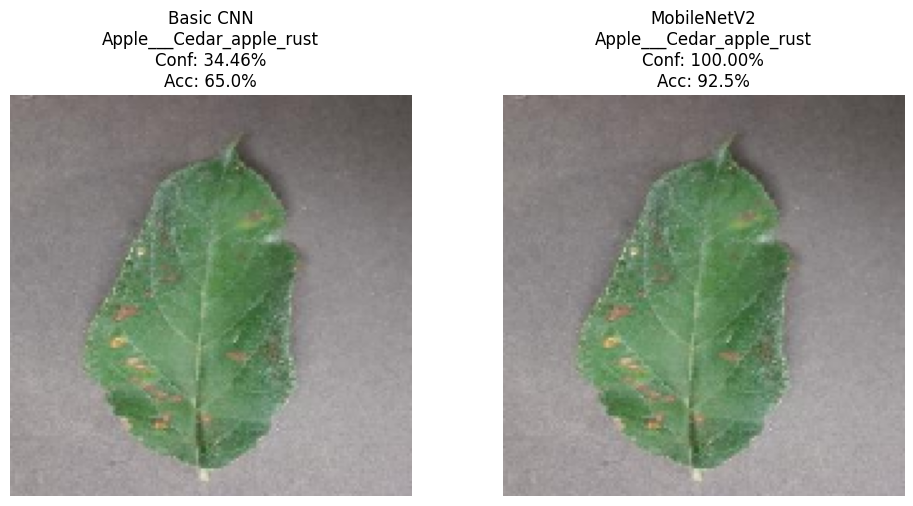

===== RESULTS =====
Basic CNN Prediction: Apple___Cedar_apple_rust
Confidence: 34.46% | Accuracy: 65.0%

MobileNetV2 Prediction: Apple___Cedar_apple_rust
Confidence: 100.00% | Accuracy: 92.5%


In [6]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import json
import matplotlib.pyplot as plt

# =========================
# LOAD BOTH MODELS
# =========================
basic_model = load_model("models/basic_cnn_model.keras")
mobilenet_model = load_model("models/mobilenetv2_finetuned.keras")

# =========================
# MODEL ACCURACY
# =========================
model_accuracies = {
    "Basic CNN": 65.0,
    "MobileNetV2": 92.5
}

# =========================
# LOAD CLASS NAMES
# =========================
with open("models/class_names.json", "r") as f:
    class_names = json.load(f)

# =========================
# LOAD IMAGE
# =========================
img_path = "test_images/testleaf.jpg"
img = image.load_img(img_path, target_size=(160,160))

# =========================
# PREPROCESS
# =========================
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# =========================
# BASIC CNN PREDICTION
# =========================
pred_basic = basic_model.predict(img_array)
class_basic = class_names[np.argmax(pred_basic)]
conf_basic = np.max(pred_basic) * 100

# =========================
# MOBILENET PREDICTION
# =========================
pred_mob = mobilenet_model.predict(img_array)
class_mob = class_names[np.argmax(pred_mob)]
conf_mob = np.max(pred_mob) * 100

# =========================
# DISPLAY SIDE-BY-SIDE
# =========================
plt.figure(figsize=(10,5))

# Basic CNN
plt.subplot(1,2,1)
plt.imshow(img)
plt.title(f"Basic CNN\n{class_basic}\nConf: {conf_basic:.2f}%\nAcc: {model_accuracies['Basic CNN']}%")
plt.axis("off")

# MobileNetV2
plt.subplot(1,2,2)
plt.imshow(img)
plt.title(f"MobileNetV2\n{class_mob}\nConf: {conf_mob:.2f}%\nAcc: {model_accuracies['MobileNetV2']}%")
plt.axis("off")

plt.tight_layout()
plt.show()

# =========================
# PRINT RESULTS
# =========================
print("===== RESULTS =====")
print("Basic CNN Prediction:", class_basic)
print(f"Confidence: {conf_basic:.2f}% | Accuracy: {model_accuracies['Basic CNN']}%")

print("\nMobileNetV2 Prediction:", class_mob)
print(f"Confidence: {conf_mob:.2f}% | Accuracy: {model_accuracies['MobileNetV2']}%")